# Daily Challenge: Breast Cancer Prediction

## 1. Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')

print('Shape:', df.shape)
df.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Unnamed: 32    569
dtype: int64


In [3]:
# Drop unnecessary columns: 'id' and the empty last column
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print('Shape after dropping:', df.shape)
df.head()

Shape after dropping: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


C:\Users\hp\AppData\Local\Temp\ipykernel_16516\1242354276.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='magma')


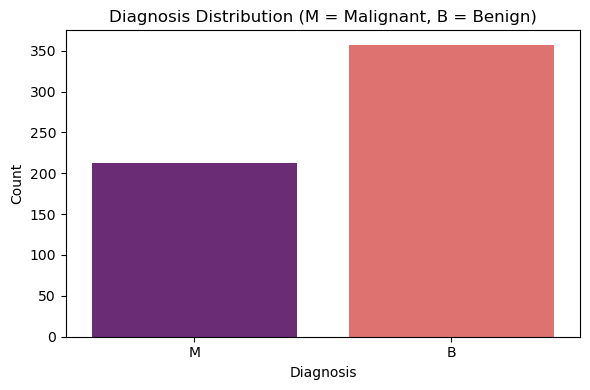

In [4]:
# Countplot of diagnosis using magma palette
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title('Diagnosis Distribution (M = Malignant, B = Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Data Preprocessing, Building Models and Evaluation

In [5]:
# Counts of unique values in diagnosis
print('Diagnosis value counts:')
print(df['diagnosis'].value_counts())

Diagnosis value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [6]:
# Map categorical values to numerical: M=1, B=0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print('After mapping:')
print(df['diagnosis'].value_counts())

After mapping:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='diagnosis')
y = df['diagnosis']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for LR, KNN, SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (455, 30)
Test size : (114, 30)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test))

# K Nearest Neighbours
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
results['KNN'] = accuracy_score(y_test, knn.predict(X_test))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
results['Random Forest'] = accuracy_score(y_test, rf.predict(X_test))

# Support Vector Machine
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
results['SVM'] = accuracy_score(y_test, svm.predict(X_test))

# Print results
print('=== Model Accuracies ===')
for model, acc in results.items():
    print(f'{model:<22}: {acc*100:.2f}%')

best = max(results, key=results.get)
print(f'\nBest model: {best} ({results[best]*100:.2f}%)')

=== Model Accuracies ===
Logistic Regression   : 97.37%
KNN                   : 94.74%
Random Forest         : 96.49%
SVM                   : 98.25%

Best model: SVM (98.25%)


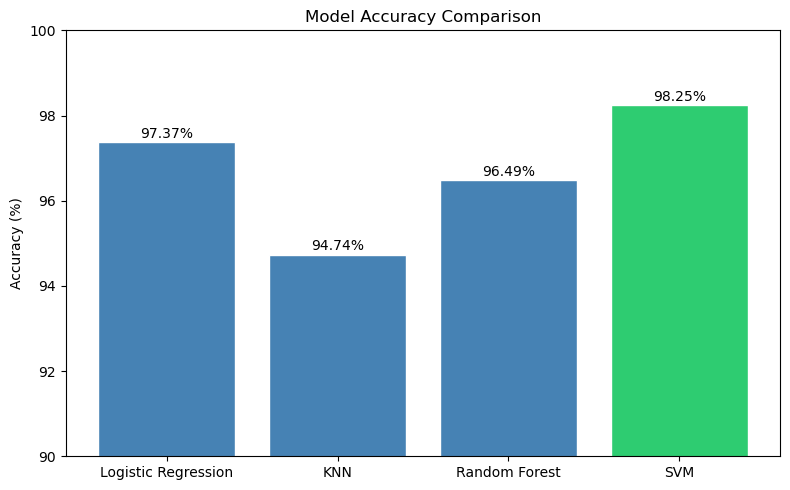

In [10]:
# Bar chart comparing all model accuracies
plt.figure(figsize=(8, 5))
colors = ['#2ecc71' if m == best else 'steelblue' for m in results.keys()]
plt.bar(results.keys(), [v * 100 for v in results.values()],
        color=colors, edgecolor='white')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)
for i, (model, acc) in enumerate(results.items()):
    plt.text(i, acc * 100 + 0.1, f'{acc*100:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()